In [57]:
import os
import re
import numpy as np
import sympy as sp
import openturns as ot
import matplotlib.pyplot as plt
import trimesh as tr

from math import pi
from joblib import Parallel, delayed

from scipy.optimize import minimize, basinhopping, \
                           differential_evolution, brute, shgo, check_grad, \
                           approx_fprime, fsolve, NonlinearConstraint, Bounds, approx_fprime

import otaf

from gldpy import GLD

ot.Log.Show(ot.Log.NONE)
np.set_printoptions(suppress=True)
ar = np.array

# Notebook for the analysis of a system comprised of N + 2 parts, 2 plates with N = N1 x N2 holes, and N pins. 

### Defintion on global descriptive parameters

In [58]:
NX = 2 ## Number of holes on x axis
NY = 1 ## Number of holes on y axis
Dext = 20 ## Diameter of holes in mm
Dint = 19.8 ## Diameter of pins in mm
EH = 50 ## Distance between the hole axises
LB = 25 # Distance between border holes axis and edge.
hPlate = 30 #Height of the plates in mm
hPin = 60 #Height of the pins in mm

CIRCLE_RESOLUTION = 8 # NUmber of points to model the contour of the outer holes

### Defining and constructing the system data dictionary

The plates have NX * NY + 1 surfaces (features). The lower left point has coordinate 0,0,0

We only model the surfaces that are touching. 

In [59]:
N_PARTS = NX * NY + 2 #Number of pins plus the 2 holed plates
LX = (NX - 1) * EH + 2*LB
LY = (NY - 1) * EH + 2*LB

contour_points = ar([[0,0,0],[LX,0,0],[LX,LY,0],[0,LY,0]])

R0 = ar([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
x_, y_, z_ = R0[0], R0[1], R0[2]

Frame1 = ar([z_,y_,-x_])
Frame2 = ar([-z_,y_,x_])

First we define the base part dictionaries for the upper and lower plate, without holes

In [60]:
system_data = {
    "PARTS" : {
        '0' : {
            "a" : {
                "FRAME": Frame1,
                "POINTS": {'A0' : ar([0,0,0]),
                           'A1' : ar([LX,0,0]),
                           'A2' : ar([LX,LY,0]),
                           'A3' : ar([0,LY,0]),
                        },
                "TYPE": "plane",
                "INTERACTIONS": ['P1a'],
                "CONSTRAINTS_D": ["PERFECT"],
                "CONSTRAINTS_G": ["SLIDING"],
            }
        },
        '1' : {
            "a" : {
                "FRAME": Frame2,
                "POINTS": {'A0' : ar([0,0,0]),
                           'A1' : ar([LX,0,0]),
                           'A2' : ar([LX,LY,0]),
                           'A3' : ar([0,LY,0]),
                        },
                "TYPE": "plane",
                "INTERACTIONS": ['P0a'],
                "CONSTRAINTS_D": ["PERFECT"],
                "CONSTRAINTS_G": ["SLIDING"],
            }
        }  
    },
    "LOOPS": {
        "COMPATIBILITY": {
        },
    },
    "GLOBAL_CONSTRAINTS": "3D",
}

Then we iterate over the pin dimensions NX and NY, and create the corresponding holes and pins. At the same time there is 1 loop per pin

In [61]:
alpha_gen = otaf.common.alphabet_generator()
next(alpha_gen) # skipping 'a' as it has already been used above
part_id = 2 # Start part index for pins
for i in range(NX):
    for j in range(NY):
        pcor = ar([LB+i*EH, LB+j*EH, 0]) # Point coordinate for hole / pins
        slab = next(alpha_gen) # Surface label, same for each mating pin so its easeir to track
        # Creating pin
        system_data["PARTS"][str(part_id)] = {}
        system_data["PARTS"][str(part_id)][slab] = {
            "FRAME": Frame1, # Frame doesn't really matter, as long as x is aligned on the axis
            "ORIGIN": pcor, 
            "TYPE": "cylinder",
            "RADIUS": Dint / 2,
            "EXTENT_LOCAL": {"x_max": hPin/2, "x_min": -hPin/2},
            "INTERACTIONS": [f"P0{slab}", f"P1{slab}"], 
            "SURFACE_DIRECTION": "centrifugal",
            "CONSTRAINTS_D": ["PERFECT"], # No defects on the pins
            "BLOCK_ROTATIONS_G": 'x', # The pins do not rotate around their axis
            "BLOCK_TRANSLATIONS_G": 'x', # The pins do not slide along their axis
        }
        # Adding hole to part 0
        system_data["PARTS"]["0"][slab] = {
            "FRAME": Frame1,
            "ORIGIN": pcor + ar([0,0,-hPlate/2]), # The cylinder modeling the hole feature is below the planar feature
            "TYPE": "cylinder",
            "RADIUS": Dext / 2,
            "EXTENT_LOCAL": {"x_max": hPlate/2, "x_min": -hPlate/2},
            "INTERACTIONS": [f"P{part_id}{slab}"], 
            "SURFACE_DIRECTION": "centripetal",
        }
        # Adding hole to part 1
        system_data["PARTS"]["1"][slab] = {
            "FRAME": Frame2,
            "ORIGIN": pcor  + ar([0,0,hPlate/2]), # The cylinder modeling the hole feature is above the planar
            "TYPE": "cylinder",
            "RADIUS": Dext / 2,
            "EXTENT_LOCAL": {"x_max": hPlate/2, "x_min": -hPlate/2},
            "INTERACTIONS": [f"P{part_id}{slab}"],
            "SURFACE_DIRECTION": "centripetal",
        }
        # Construct Compatibility loop
        loop_id = f"L{part_id-1}"
        formater = lambda i,l : f"P{i}{l}{l.upper()}0" 
        system_data["LOOPS"]["COMPATIBILITY"][loop_id] = f"P0aA0 -> {formater(0,slab)} -> {formater(part_id,slab)} -> {formater(1,slab)} -> P1aA0"
        part_id += 1  

In [62]:
SDA = otaf.AssemblyDataProcessor(system_data)
SDA.generate_expanded_loops()

In [63]:
CLH = otaf.CompatibilityLoopHandling(SDA)
compatibility_expressions = CLH.get_compatibility_expression_from_FO_matrices()

In [64]:
ILH = otaf.InterfaceLoopHandling(SDA, CLH, circle_resolution=CIRCLE_RESOLUTION)
interface_constraints = [expr.evalf(9) for expr in ILH.get_interface_loop_expressions()] 

In [65]:
SOCAM = otaf.SystemOfConstraintsAssemblyModel(
    compatibility_expressions, interface_constraints
)

SOCAM.embedOptimizationVariable()

print(len(SOCAM.deviation_symbols), SOCAM.deviation_symbols)

16 [v_d_0, w_d_0, beta_d_0, gamma_d_0, v_d_2, w_d_2, beta_d_2, gamma_d_2, v_d_5, w_d_5, beta_d_5, gamma_d_5, v_d_7, w_d_7, beta_d_7, gamma_d_7]


In [66]:
CLH.compatibility_loops_matrices

{'L1': [TransformationMatrix with index -1 and values:
  Matrix([
  [1.0, 0.0, 0.0, 15.0],
  [0.0, 1.0, 0.0, 25.0],
  [0.0, 0.0, 1.0, 25.0],
  [0.0, 0.0, 0.0,  1.0]]) and name : TP0aA0bB0,
  DeviationMatrix(index=0, translations='yz', rotations='yz', inverse=False, name=D0b),
  GapMatrix(index=0, translations_blocked='x', rotations_blocked='x', inverse=False, name=GP0bB0P2bB0),
  TransformationMatrix with index 0 and values:
  Matrix([
  [1.0, 0.0, 0.0, 0.0],
  [0.0, 1.0, 0.0, 0.0],
  [0.0, 0.0, 1.0, 0.0],
  [0.0, 0.0, 0.0, 1.0]]) and name : ,
  DeviationMatrix(index=1, translations='', rotations='', inverse=True, name=D2b),
  DeviationMatrix(index=1, translations='', rotations='', inverse=False, name=D2b),
  GapMatrix(index=1, translations_blocked='x', rotations_blocked='x', inverse=False, name=GP2bB0P1bB0),
  TransformationMatrix with index 1 and values:
  Matrix([
  [-1.0, 0.0,  0.0, 0.0],
  [ 0.0, 1.0,  0.0, 0.0],
  [ 0.0, 0.0, -1.0, 0.0],
  [ 0.0, 0.0,  0.0, 1.0]]) and name : ,
  

In [67]:
SDA

{'PARTS': {'0': {'a': {'FRAME': array([[ 0,  0,  1],
       [ 0,  1,  0],
       [-1,  0,  0]]), 'POINTS': {'A0': array([0, 0, 0]), 'A1': array([100,   0,   0]), 'A2': array([100,  50,   0]), 'A3': array([ 0, 50,  0])}, 'TYPE': 'plane', 'INTERACTIONS': ['P1a'], 'CONSTRAINTS_D': ['PERFECT'], 'CONSTRAINTS_G': ['SLIDING'], 'ORIGIN': array([0., 0., 0.])}, 'b': {'FRAME': array([[ 0,  0,  1],
       [ 0,  1,  0],
       [-1,  0,  0]]), 'ORIGIN': array([ 25.,  25., -15.]), 'TYPE': 'cylinder', 'RADIUS': 10.0, 'EXTENT_LOCAL': {'x_max': 15.0, 'x_min': -15.0}, 'INTERACTIONS': ['P2b'], 'SURFACE_DIRECTION': 'centripetal', 'POINTS': {'B0': array([ 25.,  25., -15.]), 'B1': array([ 25.,  25., -30.]), 'B2': array([25., 25.,  0.])}}, 'c': {'FRAME': array([[ 0,  0,  1],
       [ 0,  1,  0],
       [-1,  0,  0]]), 'ORIGIN': array([ 75.,  25., -15.]), 'TYPE': 'cylinder', 'RADIUS': 10.0, 'EXTENT_LOCAL': {'x_max': 15.0, 'x_min': -15.0}, 'INTERACTIONS': ['P3c'], 'SURFACE_DIRECTION': 'centripetal', 'POINTS': {

In [68]:
SDA.compatibility_loops_expanded

{'L1': 'TP0aA0bB0 -> D0b -> GP0bB0P2bB0 -> Di2b -> D2b -> GP2bB0P1bB0 -> Di1b -> TP1bB0aA0 -> D1a -> GP1aA0P0aA0 -> Di0a',
 'L2': 'TP0aA0cC0 -> D0c -> GP0cC0P3cC0 -> Di3c -> D3c -> GP3cC0P1cC0 -> Di1c -> TP1cC0aA0 -> D1a -> GP1aA0P0aA0 -> Di0a'}

In [69]:
ILH.surfaceInteractionManager.facingPointDict

defaultdict(<function otaf.common.<lambda>()>,
            {'0': defaultdict(<function otaf.common.<lambda>()>,
                         {'a': defaultdict(<function otaf.common.<lambda>()>,
                                      {'A0': {'1aA0'},
                                       'A1': {'1aA1'},
                                       'A2': {'1aA2'},
                                       'A3': {'1aA3'}}),
                          'b': defaultdict(<function otaf.common.<lambda>()>,
                                      {'B0': {'2bB0'}, 'B1': {'2bB1'}}),
                          'c': defaultdict(<function otaf.common.<lambda>()>,
                                      {'C0': {'3cC0'}, 'C1': {'3cC1'}})}),
             '1': defaultdict(<function otaf.common.<lambda>()>,
                         {'a': defaultdict(<function otaf.common.<lambda>()>,
                                      {'A0': {'0aA0'},
                                       'A1': {'0aA1'},
                               

In [70]:
compatibility_expressions

[-gamma_d_0 - gamma_d_2 - gamma_g_0 - gamma_g_1,
 beta_d_0 - beta_d_2 + beta_g_0 + beta_g_1,
 alpha_g_2,
 -25*beta_d_0 + 25*beta_d_2 - 25*beta_g_0 - 25*beta_g_1 + 25*gamma_d_0 + 25*gamma_d_2 + 25*gamma_g_0 + 25*gamma_g_1 + 30,
 15*gamma_d_0 + 15*gamma_d_2 + 15*gamma_g_0 + 15*gamma_g_1 + v_d_0 - v_d_2 + v_g_0 + v_g_1 + v_g_2,
 -15*beta_d_0 + 15*beta_d_2 - 15*beta_g_0 - 15*beta_g_1 + w_d_0 + w_d_2 + w_g_0 + w_g_1 - w_g_2,
 -gamma_d_5 - gamma_d_7 - gamma_g_3 - gamma_g_4,
 beta_d_5 - beta_d_7 + beta_g_3 + beta_g_4,
 alpha_g_2,
 -75*beta_d_5 + 75*beta_d_7 - 75*beta_g_3 - 75*beta_g_4 + 25*gamma_d_5 + 25*gamma_d_7 + 25*gamma_g_3 + 25*gamma_g_4 + 30,
 15*gamma_d_5 + 15*gamma_d_7 + 15*gamma_g_3 + 15*gamma_g_4 + v_d_5 - v_d_7 + v_g_2 + v_g_3 + v_g_4,
 -15*beta_d_5 + 15*beta_d_7 - 15*beta_g_3 - 15*beta_g_4 + w_d_5 + w_d_7 - w_g_2 + w_g_3 + w_g_4]

In [71]:
interface_constraints

[-30.0*gamma_g_0 - 1.0*v_g_0 + 0.1,
 21.2132034*beta_g_0 - 21.2132034*gamma_g_0 - 0.707106781*v_g_0 - 0.707106781*w_g_0 + 0.1,
 30.0*beta_g_0 - 1.0*w_g_0 + 0.1,
 21.2132034*beta_g_0 + 21.2132034*gamma_g_0 + 0.707106781*v_g_0 - 0.707106781*w_g_0 + 0.1,
 30.0*gamma_g_0 + 1.0*v_g_0 + 0.1,
 -21.2132034*beta_g_0 + 21.2132034*gamma_g_0 + 0.707106781*v_g_0 + 0.707106781*w_g_0 + 0.1,
 -30.0*beta_g_0 + 1.0*w_g_0 + 0.1,
 -21.2132034*beta_g_0 - 21.2132034*gamma_g_0 - 0.707106781*v_g_0 + 0.707106781*w_g_0 + 0.1,
 -30.0*gamma_g_3 - 1.0*v_g_3 + 0.1,
 21.2132034*beta_g_3 - 21.2132034*gamma_g_3 - 0.707106781*v_g_3 - 0.707106781*w_g_3 + 0.1,
 30.0*beta_g_3 - 1.0*w_g_3 + 0.1,
 21.2132034*beta_g_3 + 21.2132034*gamma_g_3 + 0.707106781*v_g_3 - 0.707106781*w_g_3 + 0.1,
 30.0*gamma_g_3 + 1.0*v_g_3 + 0.1,
 -21.2132034*beta_g_3 + 21.2132034*gamma_g_3 + 0.707106781*v_g_3 + 0.707106781*w_g_3 + 0.1,
 -30.0*beta_g_3 + 1.0*w_g_3 + 0.1,
 -21.2132034*beta_g_3 - 21.2132034*gamma_g_3 - 0.707106781*v_g_3 + 0.707106781*w

In [72]:
SOCAM.test_zero_deviation_feasibility()

{'success': False,
 'status': 2,
 'message': 'The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is At lower/fixed bound)',
 'gap_values': None,
 'objective': None}

## Construction of the stochastic model of the defects.

These are the max variances. 

In [11]:
tol = 0.1 * np.sqrt(2)
Cm = 1  # Process capability

# Defining the uncertainties on the position and orientation uncertainties.spheres_from_point_cloud
sigma_e_pos = tol / (6 * Cm)
theta_max = tol / hPlate
sigma_e_theta = (2 * theta_max) / (6 * Cm)

In [12]:
RandDeviationVect = otaf.distribution.get_composed_normal_defect_distribution(
    defect_names=SOCAM.deviation_symbols,
    sigma_dict = {"alpha":sigma_e_theta, 
                  "beta":sigma_e_theta,
                  "gamma":sigma_e_theta, 
                  "u":sigma_e_pos, 
                  "v":sigma_e_pos, 
                  "w":sigma_e_pos})
NDim_Defects = len(SOCAM.deviation_symbols)

## Estimating the bounds on the probability of failure of the model.

### Global optimization basinhopping with GLD

#### First we define the optimization functions $P_f(\Theta)$

In [13]:
#Function to store results

result_dict={}

def store_results(x, fp_gld, fp_slack, gld_params, experiment_key=None, result_dict=result_dict):
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    x_dict = {"FP_GLD": fp_gld, "FP_SLACK":fp_slack, "GLD_PARAMS": gld_params}
    if experiment_key is None:
        if x_key in result_dict.keys():
            result_dict[x_key].update(x_dict)
        else :
            result_dict[x_key] = x_dict
    else : 
        if experiment_key not in result_dict:
            result_dict[experiment_key] = {}
        if x_key in result_dict[experiment_key].keys():
            result_dict[experiment_key][x_key].update(x_dict)
        else:
            result_dict[experiment_key][x_key] = x_dict

In [14]:
SIZE_MC_PF = 100000 #int(1e6) #1e4
sample_gld = otaf.sampling.generate_and_transform_sequence(NDim_Defects, SIZE_MC_PF, RandDeviationVect) 
scale_factor = 1.0
GLD_parameters = [] # We need the parameters of the generalized lambda distribution.

result_list = [] # Will be list of lists, where each sub list is a list of the input vector x and one for the gld paramters

# Generalized lambda distribution object for fitting
gld = GLD('VSL')

def model_base(x, sample=sample_gld):
    "x is the vector of standard deviations"
    # Model without surrogate, to get slack
    x = sample * np.sqrt(x[np.newaxis, :])
    optimization_variables = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
        constraint_matrix_generator=SOCAM,
        deviation_array=x,
        batch_size=500,
        n_cpu=-1,
        progress_bar=True,
        verbose=0,
        dtype="float32",
    )
    slack_values = optimization_variables[:,-1]
    return slack_values

@otaf.optimization.scaling(scale_factor)
def optimization_function_mini(x, failure_slack=0.0, model=model_base, experiment_key=None, result_dict=result_dict):
    # Here we search the minimal probability of failure
    slack = model(x)
    gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
    
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)
    return fp_out


@otaf.optimization.scaling(scale_factor)
def optimization_function_maxi(x, failure_slack=0.0, model=model_base, experiment_key=None, result_dict=result_dict):
    # Here we search the maximal probability of failure so negative output
    slack = model(x)
    gld_params = gld.fit_LMM(slack, disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
    
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)

    return fp_out*-1

In [15]:
model_base(np.array([sigma_e_pos, sigma_e_theta]*4))

  0%|          | 0/100000 [00:00<?, ?it/s]

TypeError: Cannot cast array data from dtype('O') to dtype('float32') according to the rule 'same_kind'

### Variance (std) based parameter constraint function

In [16]:
midof_funcs = otaf.tolerances.MiSdofToleranceZones()

feature_constraint_list = []

# We know that all features are cylindrical, with same values/dimensions
for i in range(8):
    fconst = otaf.tolerances.FeatureLevelStatisticalConstraint(
        midof_funcs.cylindrical_zone,
        mif_args = (tol, hPlate),
        n_dof = 4,
        n_sample = 80000,
        target = "std", #"prob",
        target_val = sigma_e_pos*np.sqrt(1-(2/np.pi)), #0.002699, #
        isNormal = True,
        normalizeOutput = True,
    )
    feature_constraint_list.append(fconst)

# The input of this object would be a list of parameters (their real value)
composed_assembly_constraint = otaf.tolerances.ComposedAssemblyLevelStatisticalConstraint(feature_constraint_list)

In [17]:
param_bounds_one_feature = [[0.0,0.0], [0.0, sigma_e_pos], #u, mean std
                            [0.0,0.0], [0.0, sigma_e_pos], #v, mean std
                            [0.0,0.0], [0.0, sigma_e_theta], #alpha, mean std
                            [0.0,0.0], [0.0, sigma_e_theta] # beta, mean std
                           ]
param_bounds = [param_bounds_one_feature] * 8 #We have 8 identical features

# The input of this object is a list of normalized parameters (between 0 and 1)
normalized_assembly_constraint = otaf.tolerances.NormalizedAssemblyLevelConstraint(
    composed_assembly_constraint,
    param_val_bounds=param_bounds)

#### The assembly constraint takes as an input the list of list of paramters for all the features. But as the distriutions (normals) are suppposed to be centered, we only need to have the standard deviations as inputs so we construct a little intermediary class that takes as an input only the standard deviations and not the means, and completes the means with 0 to pass it to the assembly constraint. 

In [18]:
def assembly_constraint_no_mean(x, scale_factor=1.0, result_dict=result_dict, experiment_key=None):
    """ The functions takes directly the concatenated list of all normalized parameters, and reconstructs the right object.
    There should be 32 variables for the standard deviations, we just add the mean values in the vector so the input is correct 
    for the constraint object
    """
    assert len(x)==32, "problem with input."
    zer = np.zeros(4) # These are the mean values (all 0)
    pl = np.array(x)
    params_for_assembly = []
    for i in range(8):
        params = x[i*4:i*4+4]
        pa = [item for pair in zip(zer, params) for item in pair]
        params_for_assembly.append(pa)
    constraint_array =  normalized_assembly_constraint(params_for_assembly)
    
    # Storing data
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    data = {"CONST":constraint_array}
    if experiment_key is not None:
        if x_key in result_dict[experiment_key].keys():
            result_dict[experiment_key][x_key].update(data)
        else:
            result_dict[experiment_key][x_key] = data
    else :
        if x_key in result_dict.keys():
            result_dict[x_key].update(data)
        else :
            result_dict[x_key] = data

    return constraint_array * scale_factor

#### Now we create the assembly constraint for the optimization (so a non linear constraint)

In [19]:
# Define the nonlinear constraint with the updated vector-valued function and Jacobian
nonLinearConstraint = lambda resDict, expKey : NonlinearConstraint(
    fun = lambda x : assembly_constraint_no_mean(x, 1.0, resDict, expKey),
    lb  = -0.005 * np.ones((8,)),
    ub  = 0.005 * np.ones((8,)),
    keep_feasible=True,
)

In [20]:
def pf_min_max_optimizer(failure_slack=0.0, result_dict=result_dict, experiment_key=None):
    # Initial guess
    x0 = [0.5] * NDim_Defects  # Initial guess
    
    # Perform the local optimization using COBYQA directly
    res_maxi = minimize(
        optimization_function_maxi, x0,
        args=(failure_slack, model_base, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=Bounds(0.0, 1.0, keep_feasible=True),
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -1.01, 
            "maxiter": 400,
            "maxfev": 400,
            "feasibility_tol": 1e-6,
            "initial_tr_radius": np.sqrt(2*10),
            "final_tr_radius": 1e-5,
            "disp": False,
            "scale": False
        }
    )
    print('Maximization result:\n', res_maxi)
    
    # Perform the local optimization using COBYQA directly
    res_mini = minimize(
        optimization_function_mini, x0, 
        args=(failure_slack, model_base, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=Bounds(1e-16, 1.0, keep_feasible=True),
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -0.01,
            "maxiter": 400,
            "maxfev": 400,
            "feasibility_tol": 1e-6,
            "initial_tr_radius": np.sqrt(2*10),
            "final_tr_radius": 1e-5,
            "disp": False,
            "scale": False
        }
    )

    print("Minimization result:\n", res_mini)

    # Get gld params and fp.
    
    s_x_min = otaf.common.bidirectional_string_to_array_conversion(res_mini.x)
    s_x_max = otaf.common.bidirectional_string_to_array_conversion(res_maxi.x)
    
    if experiment_key :
        gld_min = result_dict[experiment_key][s_x_min]['GLD_PARAMS']
        gld_max = result_dict[experiment_key][s_x_max]['GLD_PARAMS']
        fp_min = result_dict[experiment_key][s_x_min]['FP_GLD']
        fp_max = result_dict[experiment_key][s_x_max]['FP_GLD']
    else :
        gld_min = result_dict[s_x_min]['GLD_PARAMS']
        gld_max = result_dict[s_x_max]['GLD_PARAMS']
        fp_min = result_dict[s_x_min]['FP_GLD']
        fp_max = result_dict[s_x_max]['FP_GLD']

    return (res_mini.x, res_maxi.x), (gld_min, gld_max), (fp_min, fp_max)

In [21]:
#res_x_000, res_gld_000, res_fp_000 = pf_min_max_optimizer(0.0, result_dict, "experiment_slack00")
res_x_005, res_gld_005, res_fp_005 = pf_min_max_optimizer(0.05, result_dict, "experiment_slack005")
#res_x_006, res_gld_006, res_fp_006 = pf_min_max_optimizer(0.06, result_dict, "experiment_slack006")
#res_x_001, res_gld_001, res_fp_001 = pf_min_max_optimizer(0.01, result_dict, "experiment_slack001")
#res_x_002, res_gld_002, res_fp_002 = pf_min_max_optimizer(0.02, result_dict, "experiment_slack002")
#res_x_003, res_gld_003, res_fp_003 = pf_min_max_optimizer(0.02, result_dict, "experiment_slack003")


  0%|          | 0/100000 [00:00<?, ?it/s]

TypeError: Cannot cast array data from dtype('O') to dtype('float32') according to the rule 'same_kind'

(array([0.0549701 , 0.01416723, 0.37598498, 0.12579543]), array([0.04355761, 0.02395274, 0.35510019, 0.13086283]))


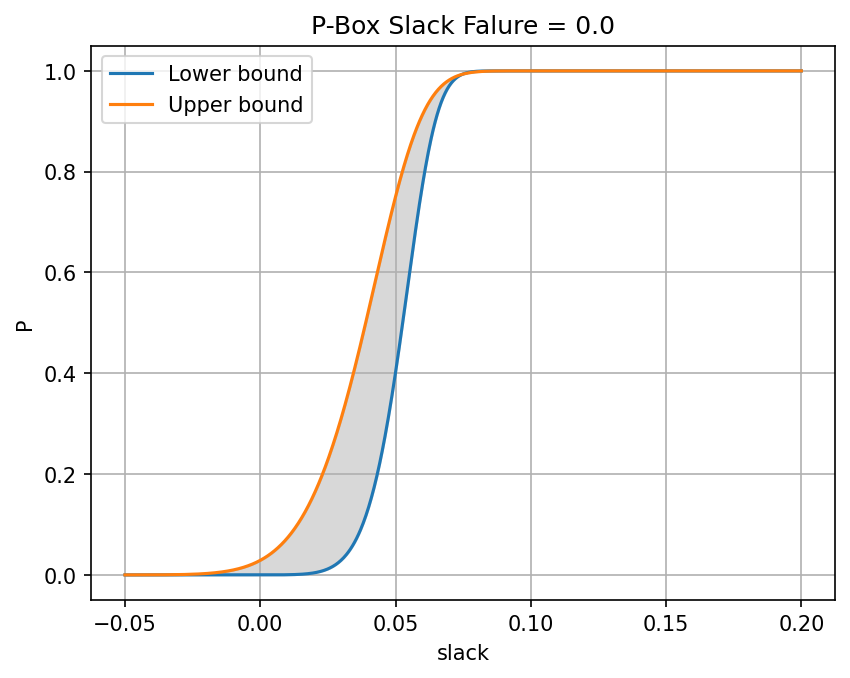

In [34]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_000, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")

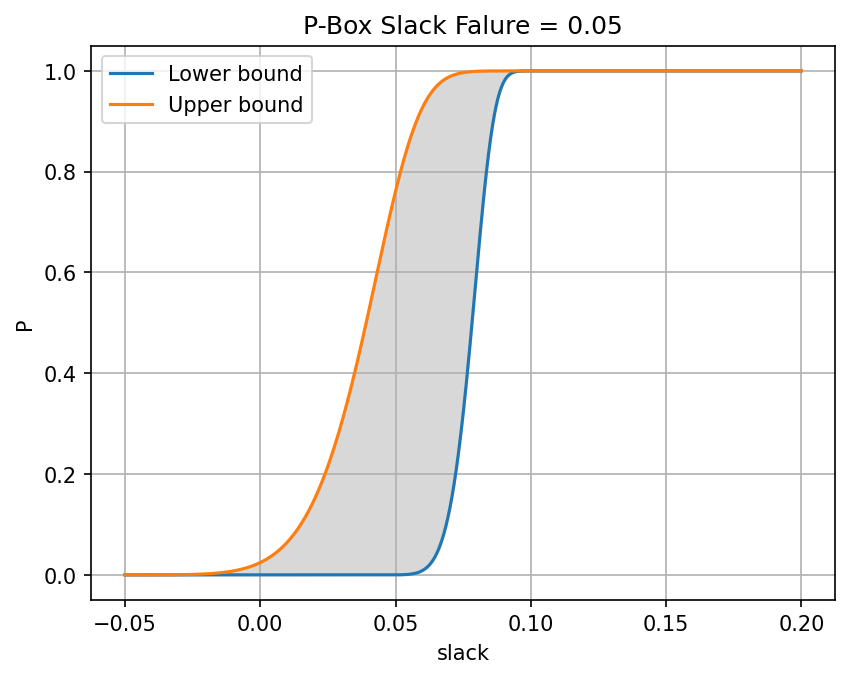

In [30]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_005, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.05")

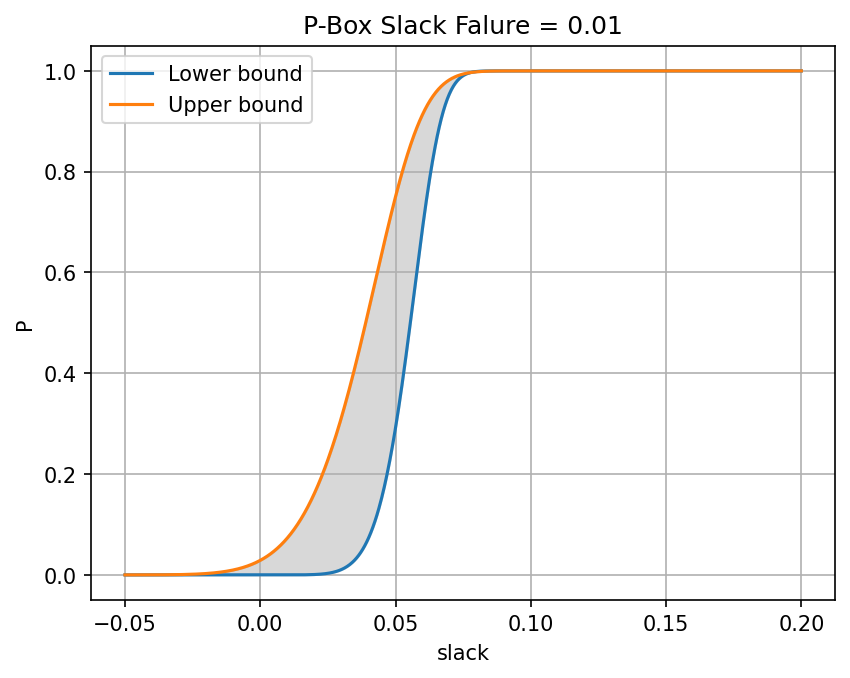

In [31]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_001, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.01")

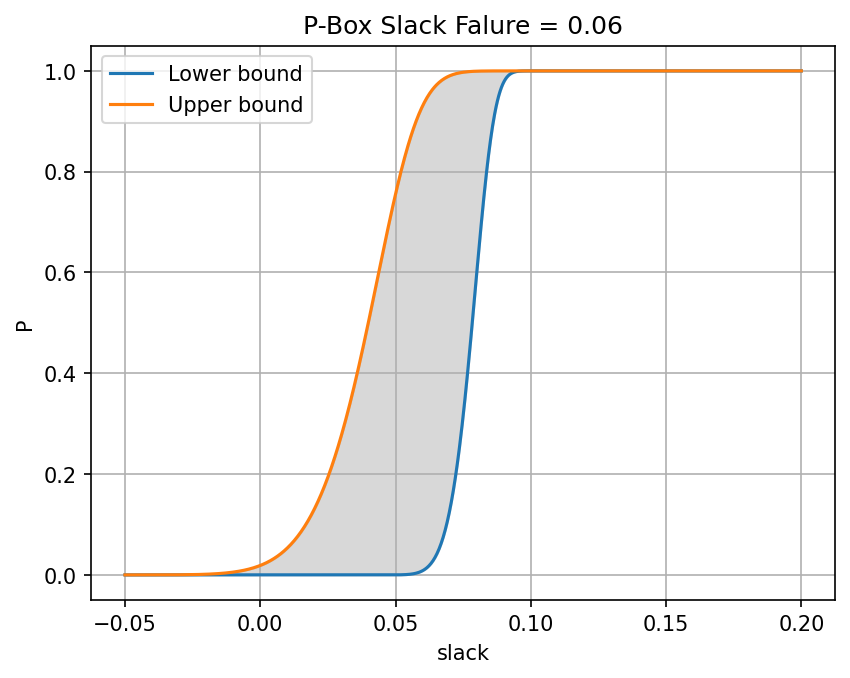

In [32]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_006, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.06")

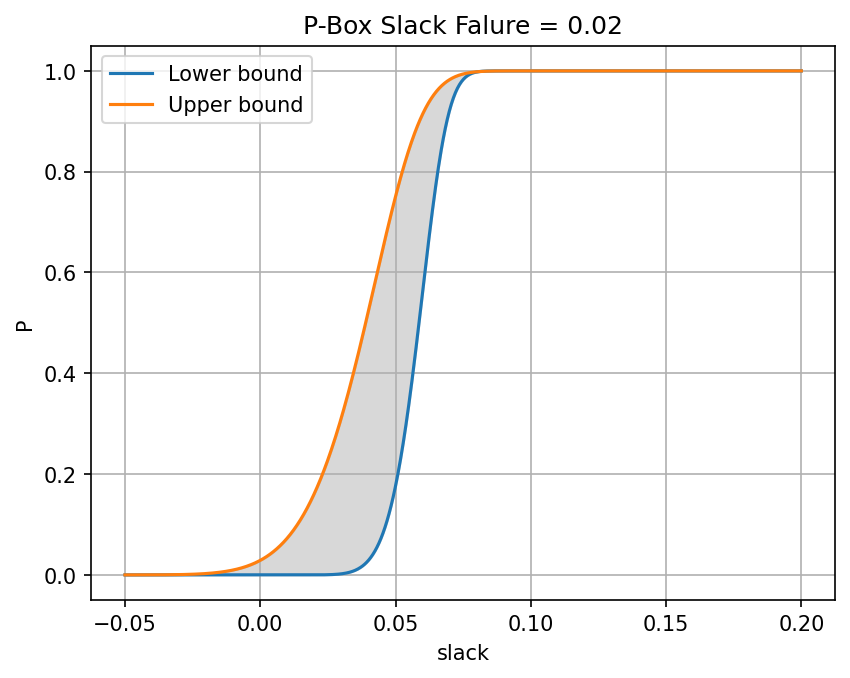

In [35]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_002, np.linspace(-0.05,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.02")

In [ ]:
# Basinhopping for the maximization function using COBYQA
x0_maxi = [0.25] * NDim_Defects  # Initial guess

# Update minimizer_kwargs_maxi to use COBYQA
minimizer_kwargs_maxi = {
    "method": "COBYQA",   # Use COBYQA method
    "args": (model_base,),     # Update args to match COBYQA requirements
    "constraints": nonLinearConstraint,
    "bounds": Bounds(lb=0.0,ub=1.0, keep_feasible=True),
    "options": {
        "f_target": -0.1, 
        "maxiter": 1000,
        "maxfev": 4000,
        "feasibility_tol": 1e-9, # tol on constraint violation
        "initial_tr_radius": np.sqrt(2*32),
        "final_tr_radius": 1e-4,
        "disp": True
    }
}

# Running basinhopping with COBYQA as the local optimizer
res_maxi = basinhopping(
    optimization_function_maxi, x0_maxi,
    niter=5,
    T=1,
    stepsize=3.0,
    niter_success=19,
    interval=5,
    minimizer_kwargs=minimizer_kwargs_maxi,
    disp=True,
    #take_step=step_taking,
    #accept_test=accept_test,
    #callback=callback
)

print("Maximization Result with COBYQA:")
print(res_maxi)

In [ ]:
res_maxi.x.round(3)

In [ ]:
N = ot.Normal()
func = ot.SymbolicFunction(["x"], ["abs(x)"])